![lop](../../images/logo_diive1_128px.png)

<span style='font-size:40px; display:block;'>
<b>
    Ustar filtering
</b>
</br>

---

# **BACKGROUND**

---

Filtering NEE, FN2O and FCH4 using the seasonal ustar thresholds detected with ReddyProc.
The purpose is to exclude fluxes calculated in periods with insufficient turbulence, thus avoiding biases in fluxes.

---

# **IMPORTS**

---

In [1]:
import importlib.metadata
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats
import seaborn as sns

from diive.core.dfun.stats import sstats  # Time series stats
from diive.core.io.files import save_parquet, load_parquet
from diive.core.plotting.timeseries import TimeSeries  # For simple (interactive) time series plotting
from diive.core.plotting.heatmap_datetime import HeatmapDateTime, HeatmapYearMonth

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.89.0


---

# **LOAD DATA**

---

In [2]:
FILEPATH = r"71.1_FLUXES_METEO_MGMT_L3.2_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet"
maindf = load_parquet(filepath=FILEPATH)
maindf

Loaded .parquet file 71.1_FLUXES_METEO_MGMT_L3.2_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet (0.623 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,BADM_HEIGHTC,BADM_INSTPAIR_EASTWARD_SEP_GA_CH4,BADM_INSTPAIR_EASTWARD_SEP_GA_CO2,BADM_INSTPAIR_EASTWARD_SEP_GA_H2O,BADM_INSTPAIR_EASTWARD_SEP_GA_N2O,BADM_INSTPAIR_HEIGHT_SEP_GA_CH4,BADM_INSTPAIR_HEIGHT_SEP_GA_CO2,BADM_INSTPAIR_HEIGHT_SEP_GA_H2O,BADM_INSTPAIR_HEIGHT_SEP_GA_N2O,...,FCH4_L3.1_L3.2_QCF0,Ustar_U16_Thres_reddyproc,Ustar_U50_Thres_reddyproc,Ustar_U84_Thres_reddyproc,NEE_U16_f_reddyproc,NEE_U50_f_reddyproc,NEE_U84_f_reddyproc,GPP_U16_f_reddyproc,GPP_U50_f_reddyproc,GPP_U84_f_reddyproc,Reco_U16_reddyproc,Reco_U50_reddyproc,Reco_U84_reddyproc,LE_f_reddyproc,H_f_reddyproc
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-31 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-01 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-01 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-01 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-01 01:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-05 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-05 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Select the variables we are interested in

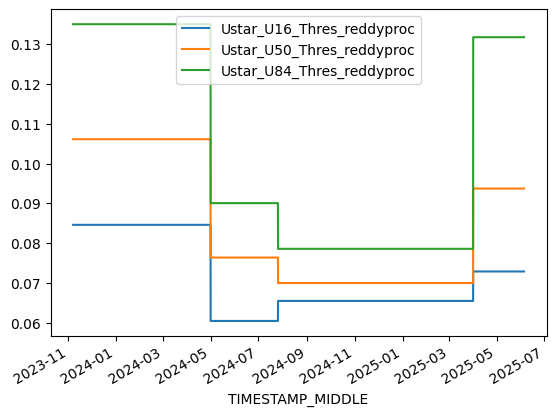

In [3]:
USTAR_SCENARIOS = ['Ustar_U16_Thres_reddyproc', 'Ustar_U50_Thres_reddyproc', 'Ustar_U84_Thres_reddyproc']
maindf[USTAR_SCENARIOS].plot(x_compat=True);

In [4]:
FLUX_VARS = [c for c in maindf.columns if 'L3.1_L3.2' in c]
TO_BE_FILTERED = ['NEE', 'FN2O', 'FCH4']
VARS_TO_FILTER = [c for c in FLUX_VARS if c.startswith(tuple(TO_BE_FILTERED))]
maindf[VARS_TO_FILTER]

,NEE_L3.1_L3.2_QCF,NEE_L3.1_L3.2_QCF0,FN2O_L3.1_L3.2_QCF,FN2O_L3.1_L3.2_QCF0,FCH4_L3.1_L3.2_QCF,FCH4_L3.1_L3.2_QCF0
TIMESTAMP_MIDDLE,,,,,,
2023-10-31 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-01 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-01 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-01 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-01 01:45:00,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2025-06-05 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-05 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-05 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN


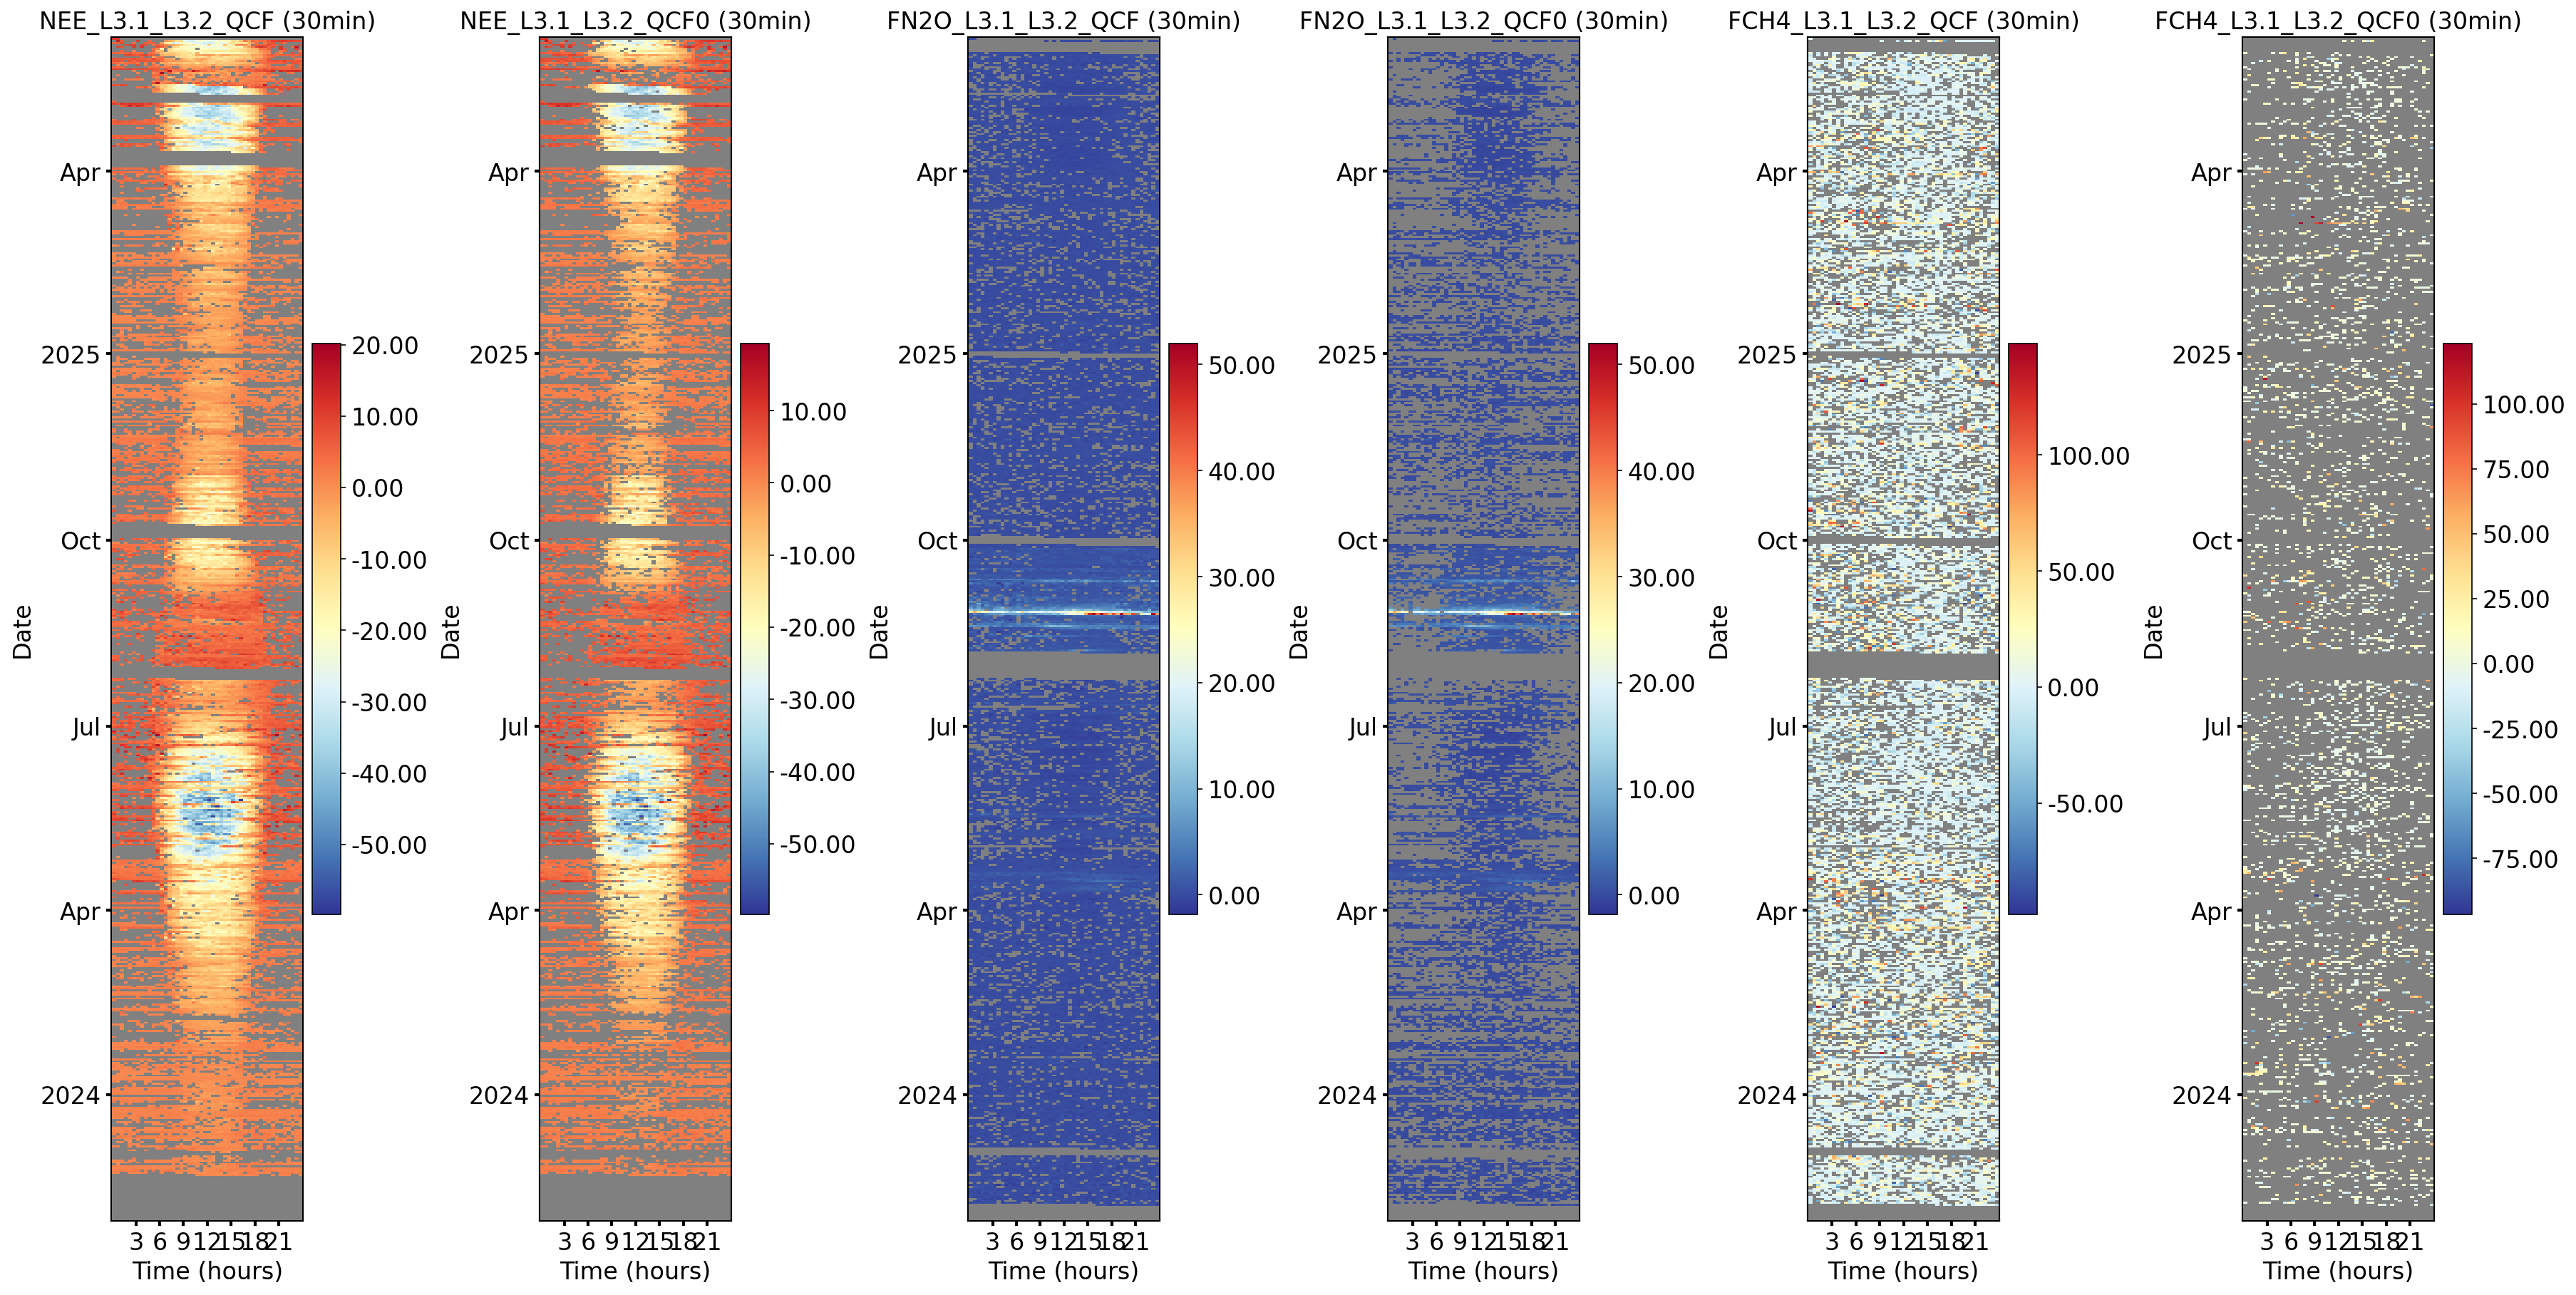

In [5]:
# Plot the fluxes that will be filtered

fig, axs = plt.subplots(ncols=6, nrows=1, figsize=(24, 12), dpi=150, layout="constrained")
axs = axs.flatten()
for ax, var in zip(axs, VARS_TO_FILTER):
    HeatmapDateTime(series=maindf[var], ax=ax).plot()

</br>

</br>

---

# **USTAR FILTERING**

---

In [6]:
df_new = maindf.copy()

for var in VARS_TO_FILTER:
    n_total = df_new[var].notna().sum()   # valid values in original variable
    for cut in USTAR_SCENARIOS:
        CUT = cut[7:9]
        name_var = f"{var.split('_', 1)[0]}_L3.3_CUT_{CUT}_{var.rsplit('_', 1)[-1]}"
        name_flag = f"FLAG_L3.3_CUT_{CUT}_{var.split('_', 1)[0]}_L3.2_{var.rsplit('_', 1)[-1]}_USTAR_TEST"
        # Initialize if new
        if name_var not in df_new:
            df_new[name_var] = np.nan
        if name_flag not in df_new:
            df_new[name_flag] = 0.0
        valid_mask = df_new[var].notna()
        mask = df_new["USTAR"] > df_new[cut]
        df_new.loc[mask & valid_mask, name_var]  = df_new.loc[mask, var]
        df_new.loc[~mask & valid_mask, name_flag] = 2.0
        # Print stats
        n_out = (df_new[name_flag] == 2.0).sum()
        pct   = 100 * n_out / n_total if n_total > 0 else np.nan
        print(f"USTAR threshold CUT_{int(CUT)} removed "
              f"{n_out} values, {pct:.1f}% of {var}")

USTAR threshold CUT_16 removed 1672 values, 9.7% of NEE_L3.1_L3.2_QCF
USTAR threshold CUT_50 removed 2407 values, 13.9% of NEE_L3.1_L3.2_QCF
USTAR threshold CUT_84 removed 3500 values, 20.2% of NEE_L3.1_L3.2_QCF
USTAR threshold CUT_16 removed 1247 values, 8.3% of NEE_L3.1_L3.2_QCF0
USTAR threshold CUT_50 removed 1791 values, 11.9% of NEE_L3.1_L3.2_QCF0
USTAR threshold CUT_84 removed 2676 values, 17.8% of NEE_L3.1_L3.2_QCF0
USTAR threshold CUT_16 removed 3251 values, 15.2% of FN2O_L3.1_L3.2_QCF
USTAR threshold CUT_50 removed 4463 values, 20.9% of FN2O_L3.1_L3.2_QCF
USTAR threshold CUT_84 removed 6059 values, 28.3% of FN2O_L3.1_L3.2_QCF
USTAR threshold CUT_16 removed 1070 values, 8.6% of FN2O_L3.1_L3.2_QCF0
USTAR threshold CUT_50 removed 1482 values, 11.9% of FN2O_L3.1_L3.2_QCF0
USTAR threshold CUT_84 removed 2152 values, 17.3% of FN2O_L3.1_L3.2_QCF0
USTAR threshold CUT_16 removed 2685 values, 16.2% of FCH4_L3.1_L3.2_QCF
USTAR threshold CUT_50 removed 3699 values, 22.3% of FCH4_L3.1_L3.2

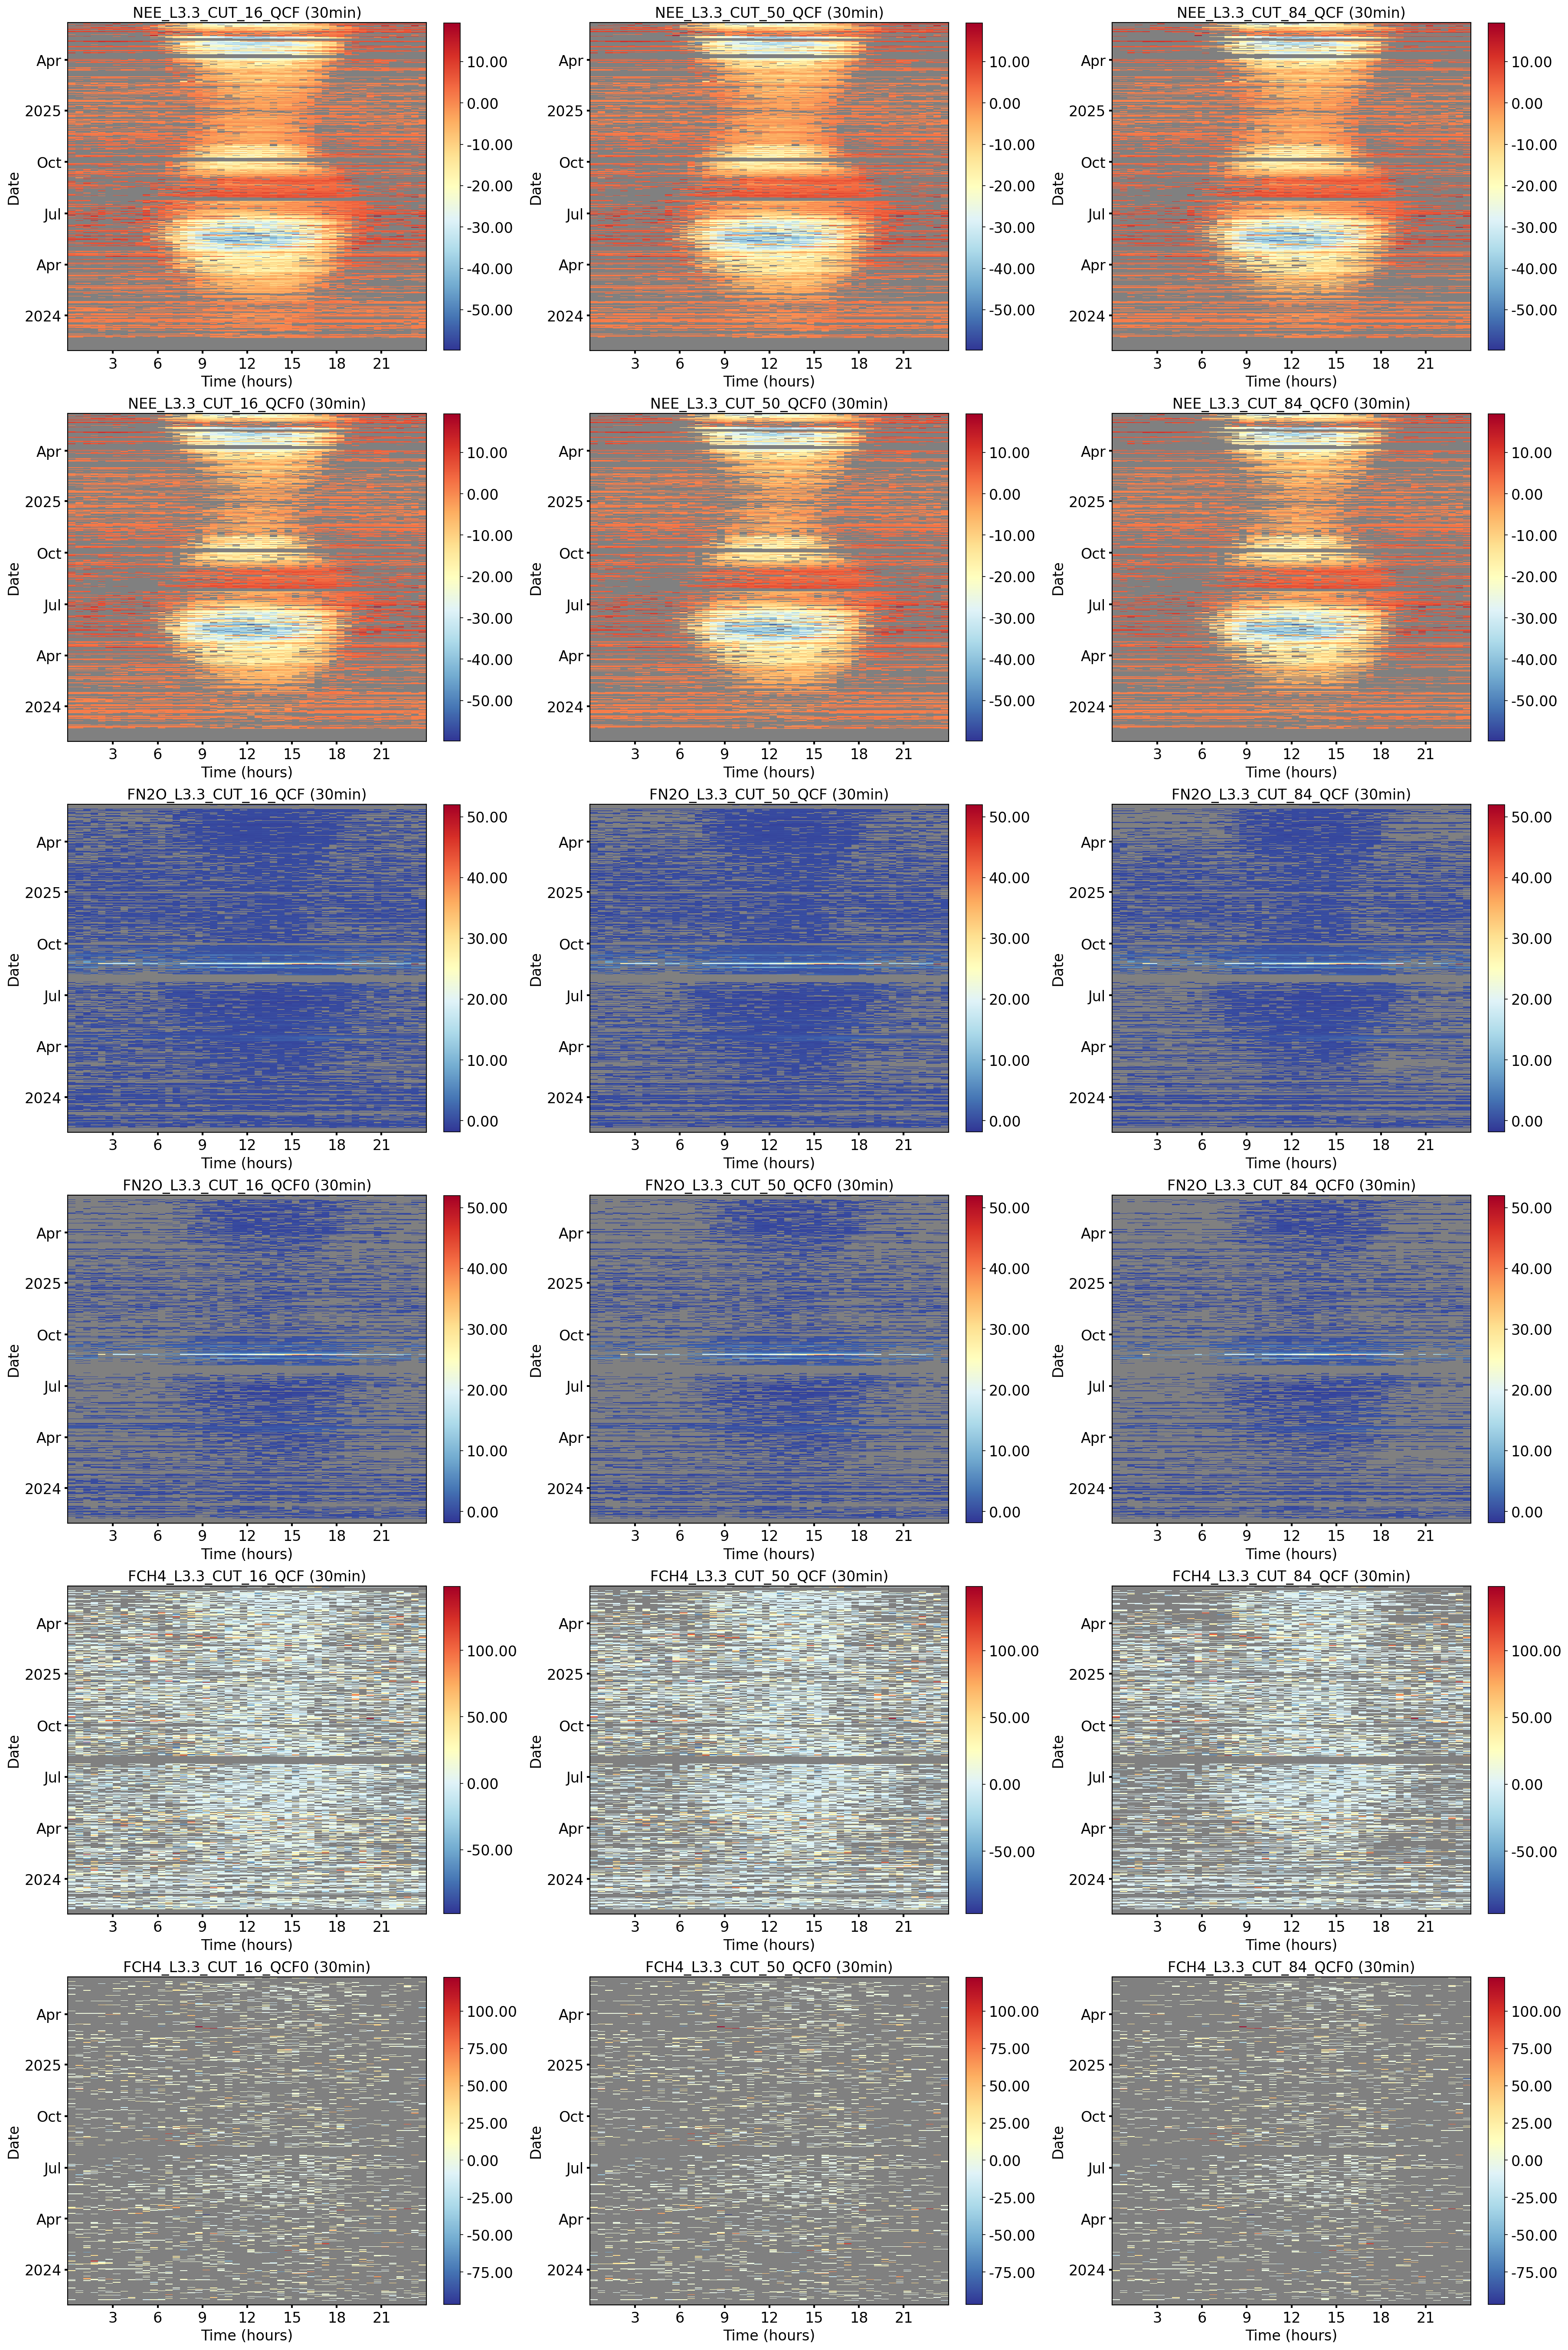

In [7]:
# Plot the ustar-filtered fluxes 
cols_to_plot  = [c for c in df_new.columns if 'CUT' in c and 'TEST' not in c]

fig, axs = plt.subplots(ncols=3, nrows=6, figsize=(24, 36), dpi=150, layout="constrained")
axs = axs.flatten()
for ax, var in zip(axs, cols_to_plot):
    HeatmapDateTime(series=df_new[var], ax=ax).plot()

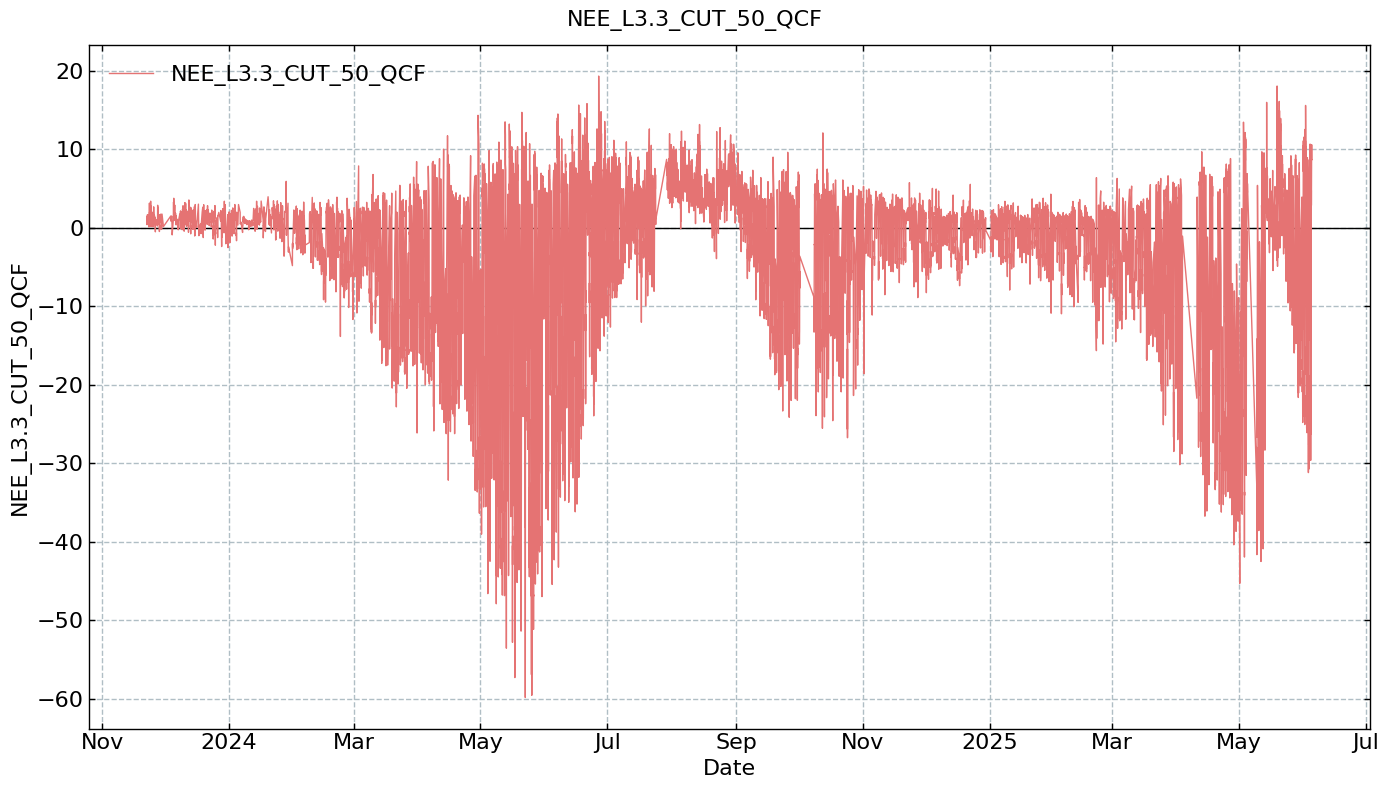

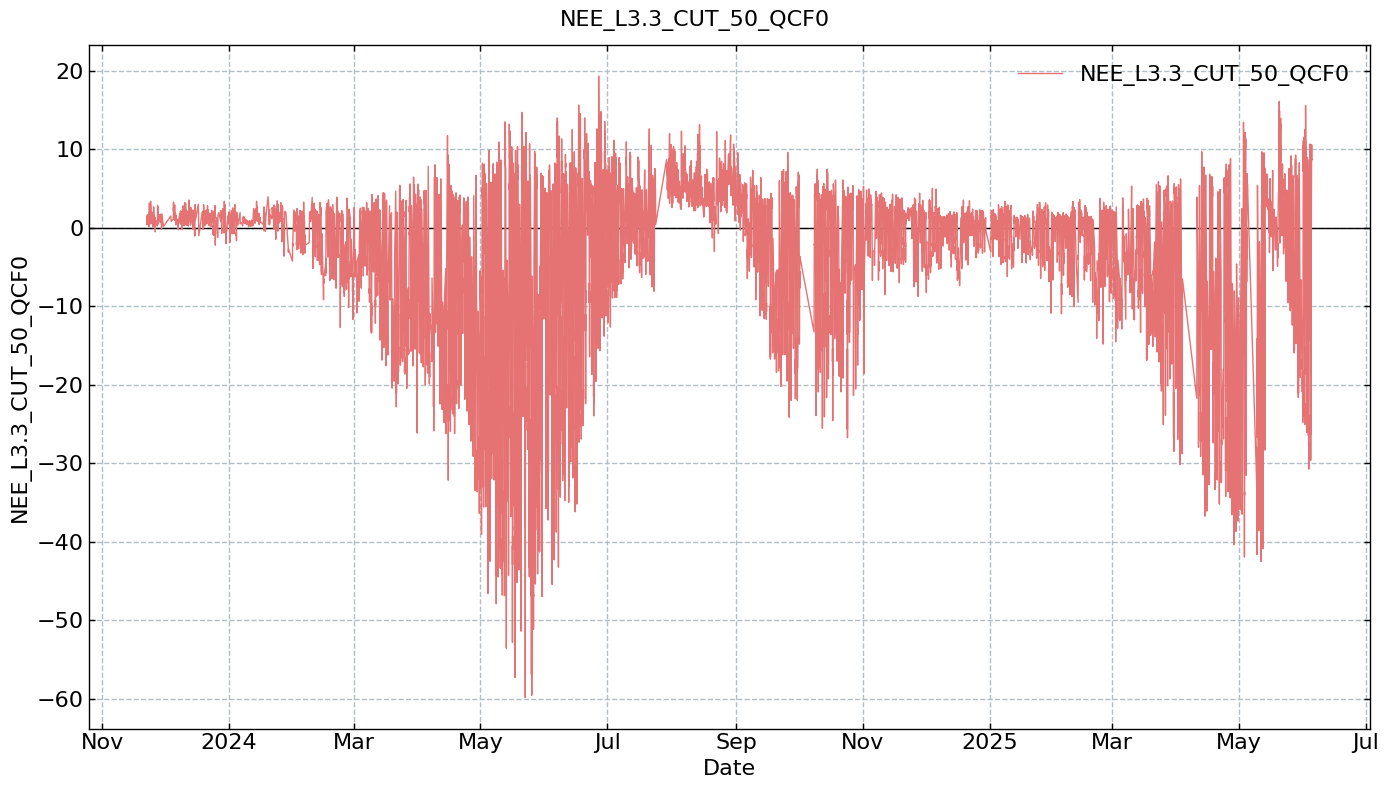

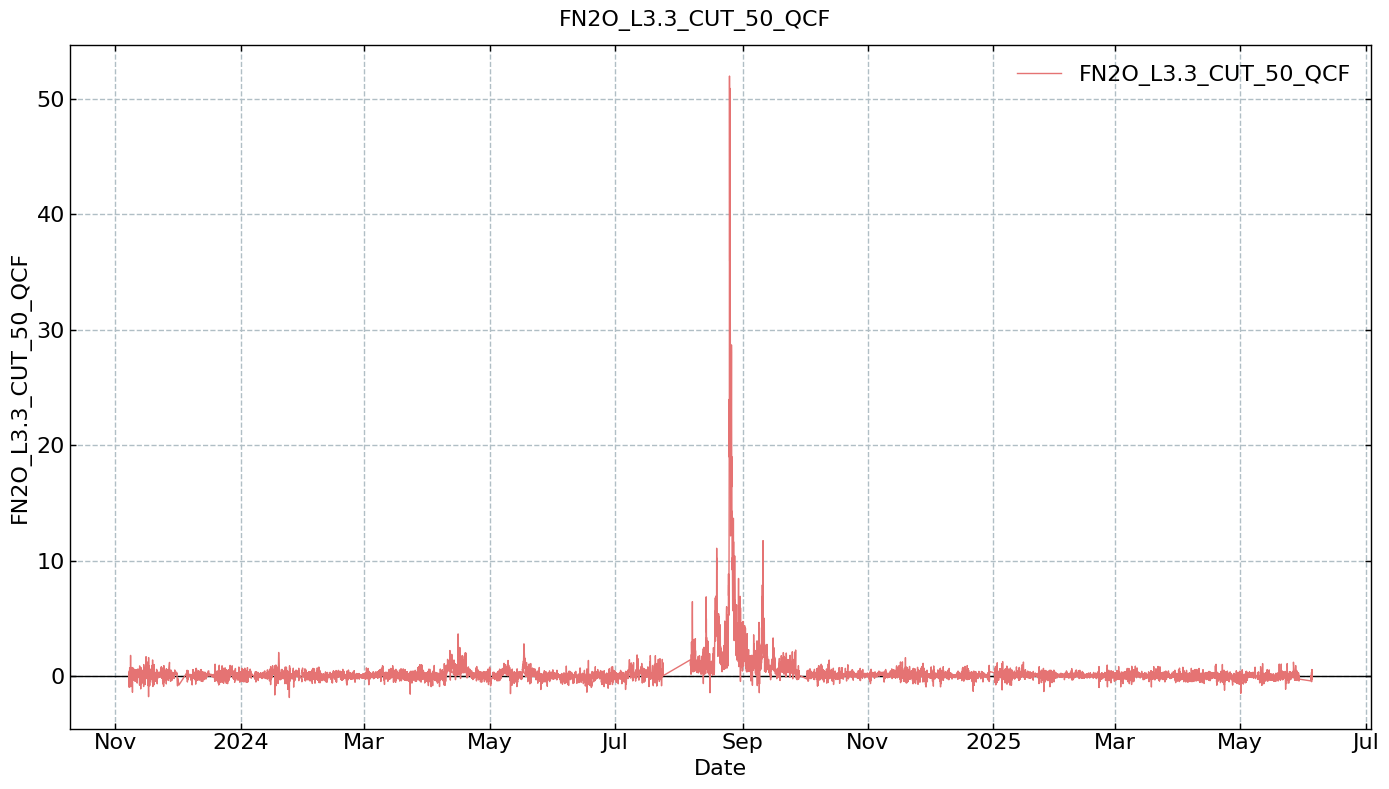

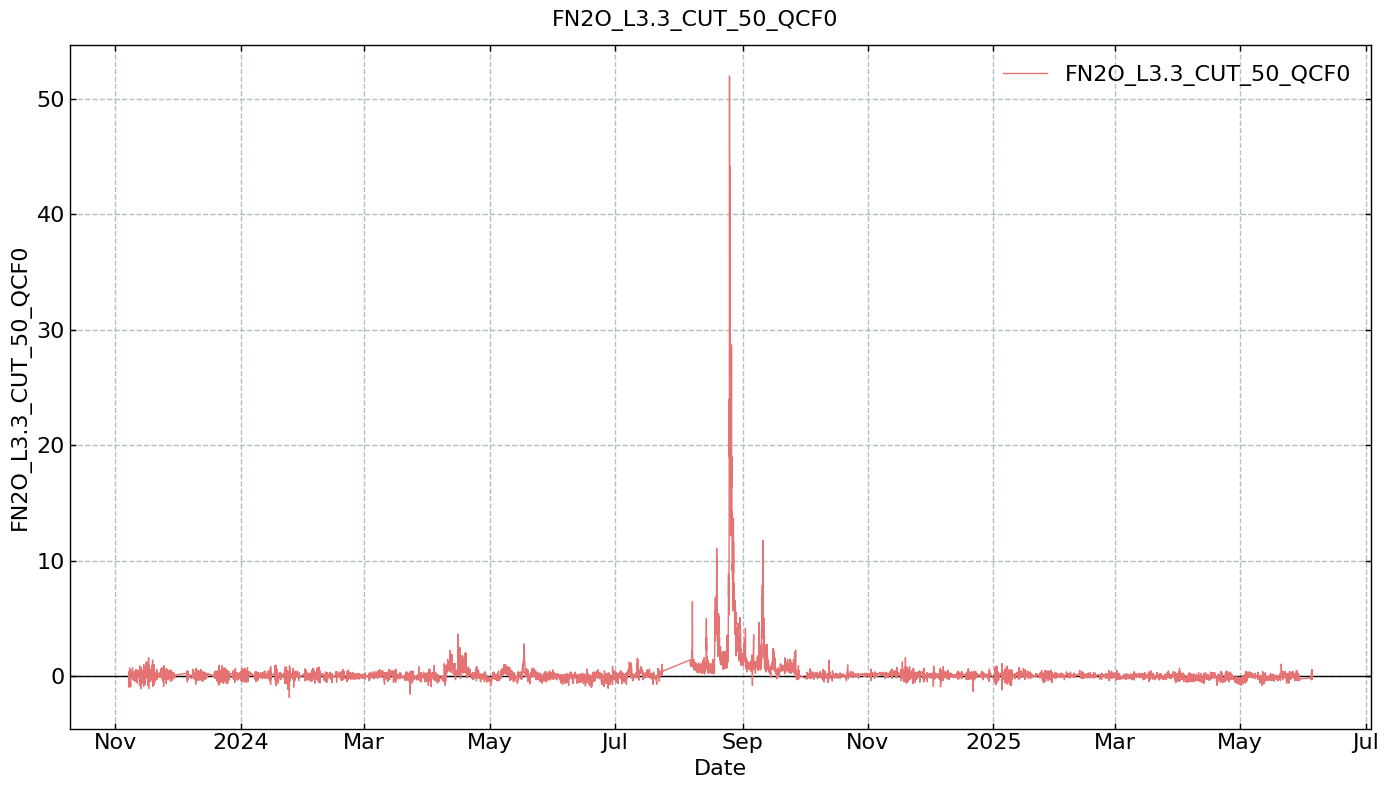

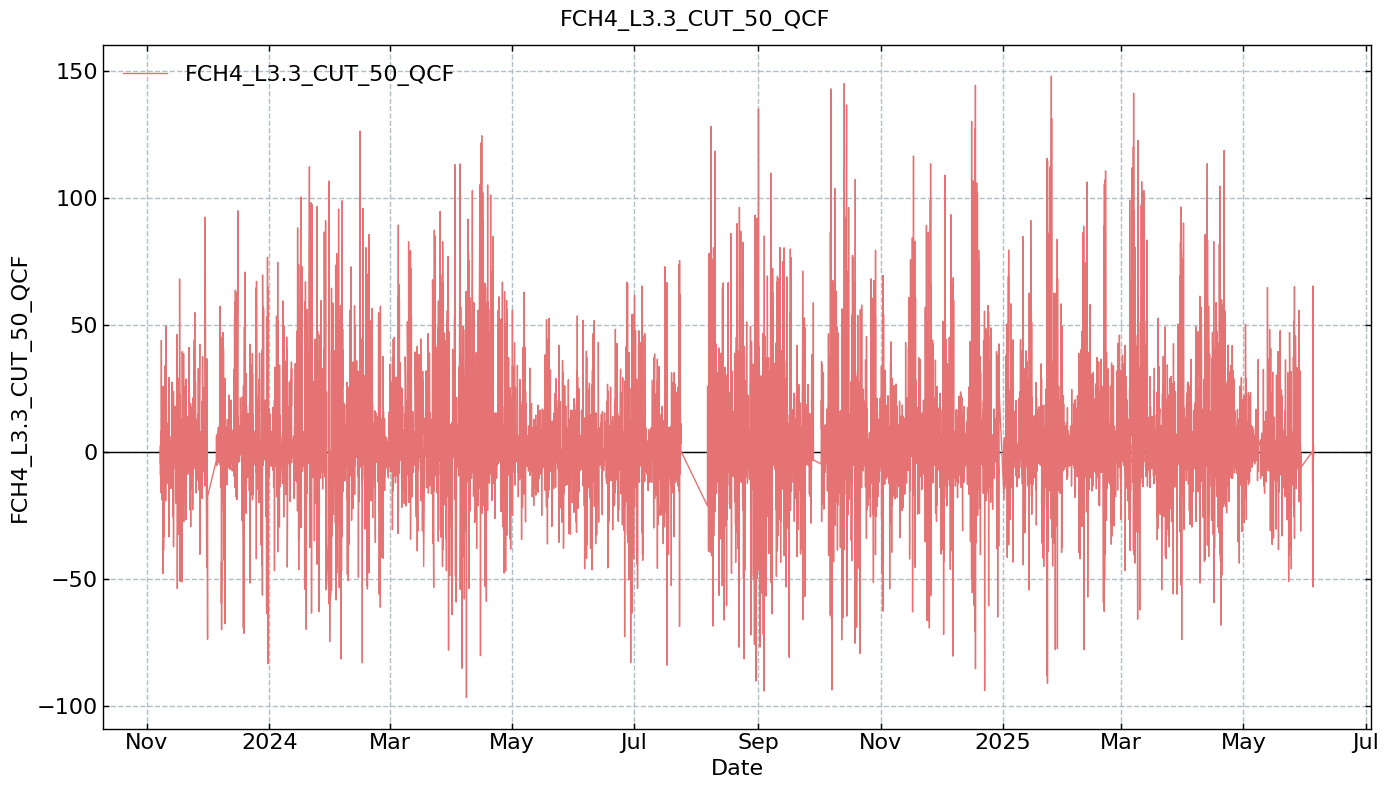

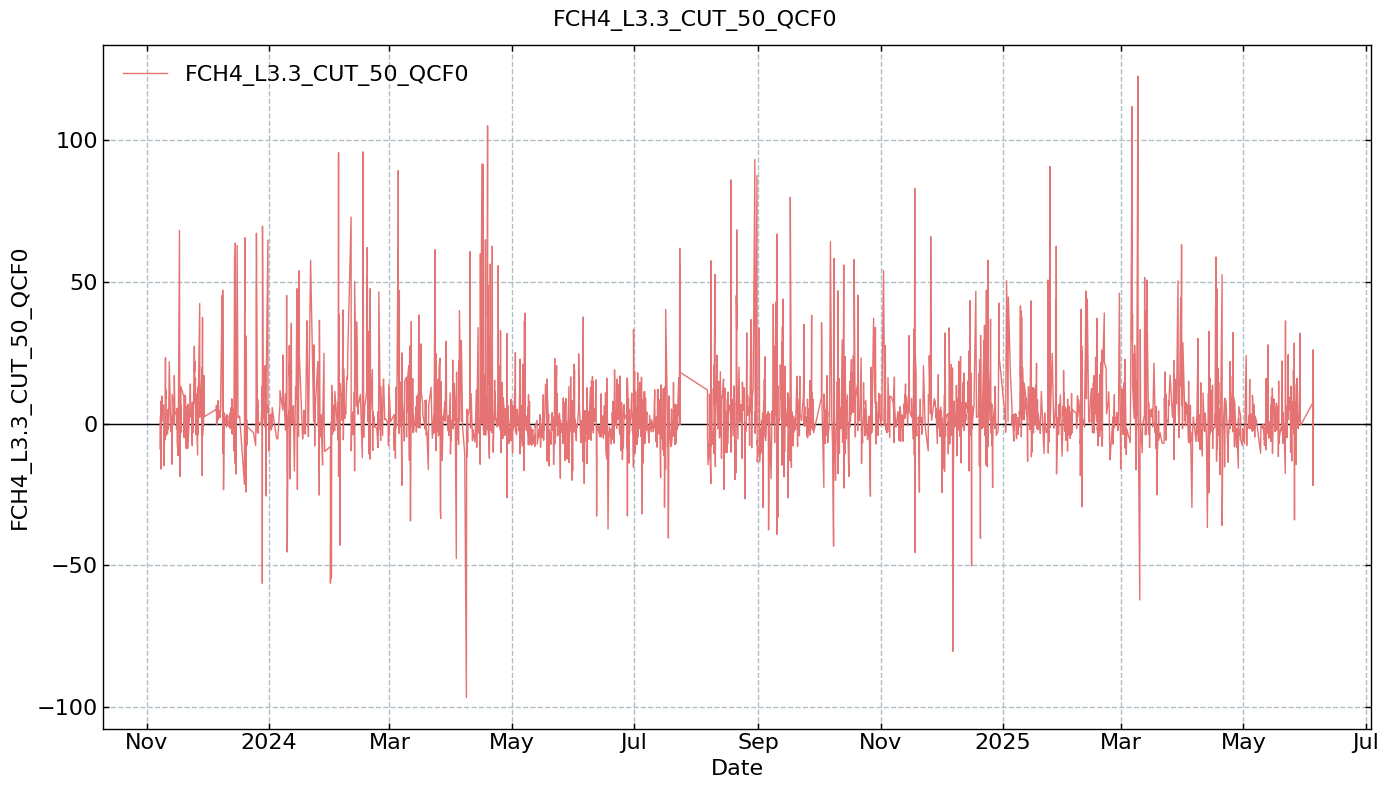

In [8]:
# Plot the variables that will be used in the next steps
for var in [c for c in cols_to_plot if '50' in c]:
    TimeSeries(series=df_new[var]).plot()

</br>

---

# **MERGE**

---

In [9]:
newcols = [c for c in df_new if c not in maindf]
print("NEW VARIABLES FROM USTAR FILTERING:")
[print(f"+ {c}") for c in newcols]
maindf = pd.concat([maindf, df_new[newcols]], axis=1)
maindf

NEW VARIABLES FROM USTAR FILTERING:
+ NEE_L3.3_CUT_16_QCF
+ FLAG_L3.3_CUT_16_NEE_L3.2_QCF_USTAR_TEST
+ NEE_L3.3_CUT_50_QCF
+ FLAG_L3.3_CUT_50_NEE_L3.2_QCF_USTAR_TEST
+ NEE_L3.3_CUT_84_QCF
+ FLAG_L3.3_CUT_84_NEE_L3.2_QCF_USTAR_TEST
+ NEE_L3.3_CUT_16_QCF0
+ FLAG_L3.3_CUT_16_NEE_L3.2_QCF0_USTAR_TEST
+ NEE_L3.3_CUT_50_QCF0
+ FLAG_L3.3_CUT_50_NEE_L3.2_QCF0_USTAR_TEST
+ NEE_L3.3_CUT_84_QCF0
+ FLAG_L3.3_CUT_84_NEE_L3.2_QCF0_USTAR_TEST
+ FN2O_L3.3_CUT_16_QCF
+ FLAG_L3.3_CUT_16_FN2O_L3.2_QCF_USTAR_TEST
+ FN2O_L3.3_CUT_50_QCF
+ FLAG_L3.3_CUT_50_FN2O_L3.2_QCF_USTAR_TEST
+ FN2O_L3.3_CUT_84_QCF
+ FLAG_L3.3_CUT_84_FN2O_L3.2_QCF_USTAR_TEST
+ FN2O_L3.3_CUT_16_QCF0
+ FLAG_L3.3_CUT_16_FN2O_L3.2_QCF0_USTAR_TEST
+ FN2O_L3.3_CUT_50_QCF0
+ FLAG_L3.3_CUT_50_FN2O_L3.2_QCF0_USTAR_TEST
+ FN2O_L3.3_CUT_84_QCF0
+ FLAG_L3.3_CUT_84_FN2O_L3.2_QCF0_USTAR_TEST
+ FCH4_L3.3_CUT_16_QCF
+ FLAG_L3.3_CUT_16_FCH4_L3.2_QCF_USTAR_TEST
+ FCH4_L3.3_CUT_50_QCF
+ FLAG_L3.3_CUT_50_FCH4_L3.2_QCF_USTAR_TEST
+ FCH4_L3.3_CUT_84_QCF
+ F

,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,BADM_HEIGHTC,BADM_INSTPAIR_EASTWARD_SEP_GA_CH4,BADM_INSTPAIR_EASTWARD_SEP_GA_CO2,BADM_INSTPAIR_EASTWARD_SEP_GA_H2O,BADM_INSTPAIR_EASTWARD_SEP_GA_N2O,BADM_INSTPAIR_HEIGHT_SEP_GA_CH4,BADM_INSTPAIR_HEIGHT_SEP_GA_CO2,BADM_INSTPAIR_HEIGHT_SEP_GA_H2O,BADM_INSTPAIR_HEIGHT_SEP_GA_N2O,...,FLAG_L3.3_CUT_50_FN2O_L3.2_QCF0_USTAR_TEST,FN2O_L3.3_CUT_84_QCF0,FLAG_L3.3_CUT_84_FN2O_L3.2_QCF0_USTAR_TEST,FCH4_L3.3_CUT_16_QCF,FLAG_L3.3_CUT_16_FCH4_L3.2_QCF_USTAR_TEST,FCH4_L3.3_CUT_50_QCF,FLAG_L3.3_CUT_50_FCH4_L3.2_QCF_USTAR_TEST,FCH4_L3.3_CUT_84_QCF,FLAG_L3.3_CUT_84_FCH4_L3.2_QCF_USTAR_TEST,FCH4_L3.3_CUT_16_QCF0,FLAG_L3.3_CUT_16_FCH4_L3.2_QCF0_USTAR_TEST,FCH4_L3.3_CUT_50_QCF0,FLAG_L3.3_CUT_50_FCH4_L3.2_QCF0_USTAR_TEST,FCH4_L3.3_CUT_84_QCF0,FLAG_L3.3_CUT_84_FCH4_L3.2_QCF0_USTAR_TEST
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-31 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2023-11-01 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2023-11-01 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2023-11-01 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2023-11-01 01:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2025-06-05 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2025-06-05 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0


---

# **EXPORT**

---

In [10]:
filename = "72.1_FLUXES_METEO_MGMT_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC"
maindf.to_csv(f"{filename}.csv", index=True)
save_parquet(data=maindf, filename=filename)

Saved file 72.1_FLUXES_METEO_MGMT_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet (2.690 seconds).


'72.1_FLUXES_METEO_MGMT_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet'

---

# **End of notebook**

---

Congratulations, you reached the end of this notebook! Before you go let's store your finish time.

In [11]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-08-28 16:51:02
